In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/processed/population_trends_lpd_2024.csv")

trend_data = pd.read_csv(DATA_PATH)

trend_data.head()

,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population,Years_Monitored,Trend,Log_Trend
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1985,2002,3.7,10.8,17,1.918919,0.920537
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1958,1987,30.0,430.0,29,13.333333,2.632121
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1977,1990,38.0,21.0,13,-0.447368,-0.572519
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1976,1990,46.0,22.0,14,-0.521739,-0.714653
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1973,1997,1.0,61.0,24,60.000000,3.433987


In [3]:
trend_data.columns

Index(['ID', 'Binomial', 'Class', 'Region', 'System', 'Latitude', 'Longitude',
       'First_Year', 'Last_Year', 'First_Population', 'Last_Population',
       'Years_Monitored', 'Trend', 'Log_Trend'],
      dtype='object')

In [4]:
required_cols = [
    "Class",
    "Common.Name",
    "Scientific.Name",
    "Region",
    "Location",
    "First_Year",
    "Last_Year",
    "First_Population",
    "Last_Population",
    "Years_Observed",
    "Log_Trend"
]

missing = [c for c in required_cols if c not in trend_data.columns]
missing

['Common.Name', 'Scientific.Name', 'Location', 'Years_Observed']

In [5]:
def classify_risk(trend):
    if trend <= -1.0:
        return "Critical decline"
    elif trend <= -0.5:
        return "High decline"
    elif trend < -0.1:
        return "Moderate decline"
    elif trend <= 0.1:
        return "Stable / near stable"
    else:
        return "Increase"

trend_data["Risk_Category"] = trend_data["Log_Trend"].apply(classify_risk)

risk_order = [
    "Critical decline",
    "High decline",
    "Moderate decline",
    "Stable / near stable",
    "Increase"
]

trend_data["Risk_Category"] = pd.Categorical(
    trend_data["Risk_Category"],
    categories=risk_order,
    ordered=True
)

In [6]:
class_risk_summary = (
    trend_data.groupby(["Class", "Risk_Category"], observed=True)
      .size()
      .reset_index(name="Population_Count")
)

class_totals = (
    trend_data.groupby("Class", observed=True)
      .size()
      .reset_index(name="Total_Populations")
)

class_risk_summary = class_risk_summary.merge(class_totals, on="Class")
class_risk_summary["Share"] = (
    class_risk_summary["Population_Count"] / class_risk_summary["Total_Populations"]
)

class_risk_summary

,Class,Risk_Category,Population_Count,Total_Populations,Share
0,Actinopteri,Critical decline,668,4847,0.137817
1,Actinopteri,High decline,406,4847,0.083763
2,Actinopteri,Moderate decline,829,4847,0.171034
3,Actinopteri,Stable / near stable,1577,4847,0.325356
4,Actinopteri,Increase,1367,4847,0.282030
5,Amphibia,Critical decline,69,205,0.336585
6,Amphibia,High decline,21,205,0.102439
7,Amphibia,Moderate decline,30,205,0.146341
8,Amphibia,Stable / near stable,32,205,0.156098
9,Amphibia,Increase,53,205,0.258537


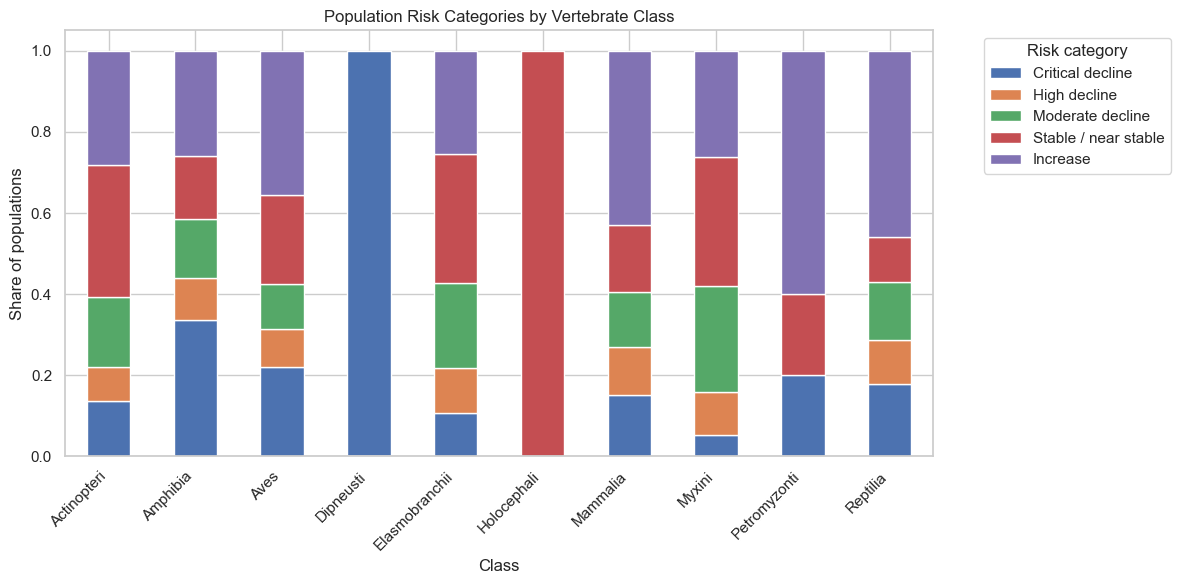

In [7]:
pivot_class_risk = class_risk_summary.pivot(
    index="Class",
    columns="Risk_Category",
    values="Share"
).fillna(0)

pivot_class_risk = pivot_class_risk[risk_order]

ax = pivot_class_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Population Risk Categories by Vertebrate Class")
plt.ylabel("Share of populations")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Risk category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("../outputs/figures/risk_categories_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
species_class_trends = (
    trend_data.groupby(["Class", "Binomial"], observed=True)
      .agg(
          Mean_Log_Trend=("Log_Trend", "mean"),
          Median_Log_Trend=("Log_Trend", "median"),
          Min_Log_Trend=("Log_Trend", "min"),
          Population_Count=("Log_Trend", "size"),
          Regions=("Region", lambda x: ", ".join(sorted(x.dropna().unique())[:5]))
      )
      .reset_index()
)

species_class_trends_filtered = (
    species_class_trends[
        species_class_trends["Population_Count"] >= 3
    ]
    .copy()
)

species_class_trends_filtered.head()

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Min_Log_Trend,Population_Count,Regions
0,Actinopteri,Abramis_brama,1.963102,0.777096,0.642860,3,Europe
1,Actinopteri,Abramites_hypselonotus,-0.174416,-0.058892,-0.810930,6,Latin America and Caribbean
2,Actinopteri,Abudefduf_bengalensis,-1.132511,-1.064711,-1.716048,3,Asia
6,Actinopteri,Abudefduf_vaigiensis,-2.130070,-2.810908,-2.898277,3,Asia
7,Actinopteri,Acanthaluteres_vittiger,-1.299264,-1.410303,-2.780677,4,Oceania


In [9]:
species_risk = (
    trend_data
    .groupby(["Class", "Binomial"], observed=True)
    .agg(
        Mean_Log_Trend=("Log_Trend", "mean"),
        Median_Log_Trend=("Log_Trend", "median"),
        Population_Count=("ID", "count")
    )
    .reset_index()
)

species_risk = species_risk[
    species_risk["Population_Count"] >= 3
]

species_risk

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count
0,Actinopteri,Abramis_brama,1.963102,0.777096,3
1,Actinopteri,Abramites_hypselonotus,-0.174416,-0.058892,6
2,Actinopteri,Abudefduf_bengalensis,-1.132511,-1.064711,3
6,Actinopteri,Abudefduf_vaigiensis,-2.130070,-2.810908,3
7,Actinopteri,Acanthaluteres_vittiger,-1.299264,-1.410303,4
...,...,...,...,...,...
3360,Reptilia,Testudo_hermanni,-0.255871,-0.087404,4
3362,Reptilia,Trachemys_scripta,-1.608307,-1.734601,3
3368,Reptilia,Vipera_aspis,-1.467230,-0.969401,3
3369,Reptilia,Vipera_berus,-0.393067,-0.433651,5


In [10]:
high_risk_populations = (
    trend_data
    .sort_values("Log_Trend")
    .head(50)
)

high_risk_populations

,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population,Years_Monitored,Trend,Log_Trend,Risk_Category
9942,19301,Trachurus_capensis,Actinopteri,Africa,Marine,-35.000000,23.000000,1950,2019,769563.0,1.203,69,-0.999998,-12.763759,Critical decline
9938,19297,Merluccius_paradoxus,Actinopteri,Africa,Marine,-34.883330,19.483330,1950,2020,1020000.0,7.244,70,-0.999993,-11.725829,Critical decline
3202,4631,Oncorhynchus_tshawytscha,Actinopteri,North America,Freshwater,38.063060,-121.851670,1967,1989,57500.0,0.000,22,-1.000000,-10.959558,Critical decline
9941,19300,Merluccius_capensis,Actinopteri,Africa,Marine,-34.883330,19.483330,1950,2020,136000.0,3.340,70,-0.999975,-10.352543,Critical decline
14709,121092,Calidris_canutus,Aves,Oceania,Marine,-18.311146,122.316321,1999,2018,13400.0,1.000,19,-0.999925,-8.809937,Critical decline
7158,12198,Aythya_marila,Aves,Asia,Freshwater,46.533300,35.316700,1991,2010,6000.0,0.000,19,-1.000000,-8.699681,Critical decline
5658,9150,Lissodelphis_borealis,Mammalia,North America,Marine,37.283330,-128.966670,1991,2014,5039.0,0.000,23,-1.000000,-8.525161,Critical decline
15772,122569,Calidris_ferruginea,Aves,Oceania,Marine,-38.321010,144.240200,1981,2020,4981.0,0.000,39,-1.000000,-8.513587,Critical decline
16104,123010,Calidris_ruficollis,Aves,Oceania,Marine,-31.915350,115.491600,1982,2020,4000.0,0.000,38,-1.000000,-8.294300,Critical decline
14701,121084,Calidris_canutus,Aves,Oceania,Marine,-18.311146,122.316321,1999,2018,13400.0,3.000,19,-0.999776,-8.116790,Critical decline


In [11]:
high_risk = trend_data[
    trend_data["Log_Trend"] <= -1
]

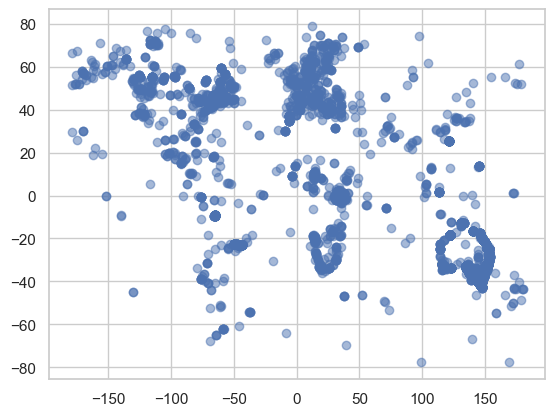

In [12]:
plt.scatter(
    high_risk["Longitude"],
    high_risk["Latitude"],
    alpha=0.5
)

In [13]:
species_risk.sort_values(
    "Mean_Log_Trend"
).head(20)

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count
128,Actinopteri,Atherina_woodwardi,-4.823440,-4.836282,3
2860,Mammalia,Damaliscus_korrigum,-3.491359,-3.521239,4
896,Actinopteri,Pomadasys_quadrilineatus,-3.214802,-3.305054,3
766,Actinopteri,Notothenia_rossii,-3.154981,-3.881564,3
2886,Mammalia,Equus_asinus,-2.947976,-3.127558,3
670,Actinopteri,Merluccius_capensis,-2.882815,-0.774232,4
1508,Aves,Aythya_nyroca,-2.812756,-3.077970,11
2620,Aves,Vini_ultramarina,-2.710909,-4.262680,3
2149,Aves,Neophema_chrysogaster,-2.550476,-2.944439,9
2371,Aves,Recurvirostra_novaehollandiae,-2.436584,-2.042243,3


In [14]:
species_risk["Population_Count"].describe()

count    1466.000000
mean       12.856753
std        42.719451
min         3.000000
25%         4.000000
50%         6.000000
75%        11.000000
max       746.000000
Name: Population_Count, dtype: float64

In [15]:
species_risk[
    species_risk["Population_Count"] >= 10
].sort_values("Mean_Log_Trend").head(20)

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count
1508,Aves,Aythya_nyroca,-2.812756,-3.077970,11
2380,Aves,Riparia_riparia,-1.852246,-2.028748,15
2874,Mammalia,Diceros_bicornis,-1.448749,-1.261798,35
836,Actinopteri,Perca_fluviatilis,-1.437102,-0.335300,13
2191,Aves,Passer_domesticus,-1.369135,-1.659572,18
1901,Aves,Gyps_coprotheres,-1.241488,-0.789493,15
2913,Mammalia,Gymnobelideus_leadbeateri,-1.185011,-1.609438,19
1568,Aves,Calidris_ferruginea,-1.168890,-0.200671,578
431,Actinopteri,Gadus_morhua,-1.144352,-1.057925,80
2219,Aves,Petrochelidon_pyrrhonota,-1.134876,-1.168774,11


In [16]:
species_risk[
    species_risk["Population_Count"] >= 20
].sort_values("Mean_Log_Trend").head(20)

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count
2874,Mammalia,Diceros_bicornis,-1.448749,-1.261798,35
1568,Aves,Calidris_ferruginea,-1.168890,-0.200671,578
431,Actinopteri,Gadus_morhua,-1.144352,-1.057925,80
2492,Aves,Sturnus_vulgaris,-1.038481,-1.076613,27
1991,Aves,Larus_canus,-0.934763,-1.031398,36
1939,Aves,Hirundo_rustica,-0.885488,-0.943507,20
3152,Mammalia,Raphicerus_campestris,-0.853268,-0.943166,28
502,Actinopteri,Hippoglossoides_platessoides,-0.845007,-0.942127,37
2867,Mammalia,Dasyurus_hallucatus,-0.801880,-0.693147,48
2034,Aves,Limosa_lapponica,-0.765082,-0.219937,584


In [17]:
species_risk["Confidence_Score"] = np.log1p(
    species_risk["Population_Count"]
)

In [18]:
species_risk["Risk_Score"] = (
    -species_risk["Median_Log_Trend"]
    * np.log1p(species_risk["Population_Count"])
)

In [19]:
species_risk.sort_values(
    "Risk_Score",
    ascending=False
).head(20)

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count,Confidence_Score,Risk_Score
1508,Aves,Aythya_nyroca,-2.812756,-3.077970,11,2.484907,7.648469
2149,Aves,Neophema_chrysogaster,-2.550476,-2.944439,9,2.302585,6.779821
128,Actinopteri,Atherina_woodwardi,-4.823440,-4.836282,3,1.386294,6.704510
2620,Aves,Vini_ultramarina,-2.710909,-4.262680,3,1.386294,5.909329
2860,Mammalia,Damaliscus_korrigum,-3.491359,-3.521239,4,1.609438,5.667216
2380,Aves,Riparia_riparia,-1.852246,-2.028748,15,2.772589,5.624885
766,Actinopteri,Notothenia_rossii,-3.154981,-3.881564,3,1.386294,5.380990
1651,Aves,Chloebia_gouldiae,-2.256242,-2.545531,7,2.079442,5.293283
3157,Mammalia,Redunca_redunca,-2.107527,-2.397895,7,2.079442,4.986283
2191,Aves,Passer_domesticus,-1.369135,-1.659572,18,2.944439,4.886509


In [20]:
species_risk["Mean_Median_Diff"] = (
    species_risk["Mean_Log_Trend"]
    - species_risk["Median_Log_Trend"]
).abs()

In [21]:
species_risk.sort_values(
    ["Mean_Log_Trend", "Mean_Median_Diff"]
).head(20)

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count,Confidence_Score,Risk_Score,Mean_Median_Diff
128,Actinopteri,Atherina_woodwardi,-4.823440,-4.836282,3,1.386294,6.704510,0.012842
2860,Mammalia,Damaliscus_korrigum,-3.491359,-3.521239,4,1.609438,5.667216,0.029880
896,Actinopteri,Pomadasys_quadrilineatus,-3.214802,-3.305054,3,1.386294,4.581777,0.090252
766,Actinopteri,Notothenia_rossii,-3.154981,-3.881564,3,1.386294,5.380990,0.726583
2886,Mammalia,Equus_asinus,-2.947976,-3.127558,3,1.386294,4.335716,0.179582
670,Actinopteri,Merluccius_capensis,-2.882815,-0.774232,4,1.609438,1.246078,2.108583
1508,Aves,Aythya_nyroca,-2.812756,-3.077970,11,2.484907,7.648469,0.265214
2620,Aves,Vini_ultramarina,-2.710909,-4.262680,3,1.386294,5.909329,1.551771
2149,Aves,Neophema_chrysogaster,-2.550476,-2.944439,9,2.302585,6.779821,0.393963
2371,Aves,Recurvirostra_novaehollandiae,-2.436584,-2.042243,3,1.386294,2.831150,0.394341


In [22]:
species_risk["Population_Count"].describe()

count    1466.000000
mean       12.856753
std        42.719451
min         3.000000
25%         4.000000
50%         6.000000
75%        11.000000
max       746.000000
Name: Population_Count, dtype: float64

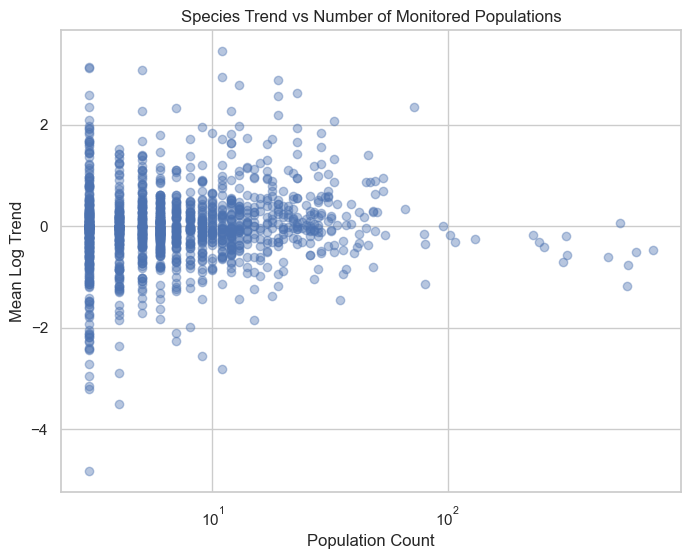

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    species_risk["Population_Count"],
    species_risk["Mean_Log_Trend"],
    alpha=0.4
)

plt.xscale("log")

plt.xlabel("Population Count")
plt.ylabel("Mean Log Trend")
plt.title("Species Trend vs Number of Monitored Populations")

plt.show()

In [24]:
well_monitored = species_risk[
    species_risk["Population_Count"] >= 100
]

well_monitored.sort_values("Median_Log_Trend").head(20)

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count,Confidence_Score,Risk_Score,Mean_Median_Diff
2156,Aves,Numenius_madagascariensis,-0.617025,-0.559616,480,6.175867,3.456113,0.057410
2021,Aves,Leipoa_ocellata,-0.320276,-0.405465,108,4.691348,1.902178,0.085189
2034,Aves,Limosa_lapponica,-0.765082,-0.219937,584,6.371612,1.401354,0.545145
1568,Aves,Calidris_ferruginea,-1.168890,-0.200671,578,6.361302,1.276527,0.968219
3101,Mammalia,Phascolarctos_cinereus,-0.171654,-0.115577,102,4.634729,0.535666,0.056077
1580,Aves,Calidris_ruficollis,-0.467254,-0.067311,746,6.616065,0.445337,0.399943
1563,Aves,Calidris_acuminata,0.055731,0.000000,542,6.297109,-0.000000,0.055731
1566,Aves,Calidris_canutus,-0.194287,0.000000,318,5.765191,-0.000000,0.194287
1583,Aves,Calidris_tenuirostris,-0.571812,0.000000,322,5.777652,-0.000000,0.571812
1636,Aves,Charadrius_leschenaultii,-0.184191,0.000000,230,5.442418,-0.000000,0.184191


In [25]:
species_risk.sort_values(
    "Mean_Median_Diff",
    ascending=False
).head(20)

,Class,Binomial,Mean_Log_Trend,Median_Log_Trend,Population_Count,Confidence_Score,Risk_Score,Mean_Median_Diff
670,Actinopteri,Merluccius_capensis,-2.882815,-0.774232,4,1.609438,1.246078,2.108583
939,Actinopteri,Pseudorasbora_parva,2.086749,0.445222,3,1.386294,-0.617209,1.641527
2620,Aves,Vini_ultramarina,-2.710909,-4.262680,3,1.386294,5.909329,1.551771
2675,Elasmobranchii,Carcharhinus_limbatus,-1.706766,-0.299517,5,1.791759,0.536662,1.407250
2494,Aves,Sula_leucogaster,1.819024,3.129680,3,1.386294,-4.338658,1.310657
2002,Aves,Larus_melanocephalus,2.786383,1.504077,13,2.639057,-3.969346,1.282306
3060,Mammalia,Onychogalea_fraenata,-0.838455,-2.083007,4,1.609438,3.352471,1.244553
2543,Aves,Thalasseus_sandvicensis,1.838738,0.601073,29,3.401197,-2.044366,1.237666
2914,Mammalia,Halichoerus_grypus,2.344277,1.128693,72,4.290459,-4.842611,1.215584
1534,Aves,Bubulcus_ibis,3.442348,2.231742,11,2.484907,-5.545669,1.210607


In [26]:
well_monitored.sort_values(
    "Median_Log_Trend"
).to_csv(
    "../outputs/well_monitored_species_risk.csv",
    index=False
)

In [27]:
species_risk["Species_Risk"] = pd.cut(
    species_risk["Median_Log_Trend"],
    bins=[-np.inf, -0.5, -0.1, 0.1, np.inf],
    labels=[
        "High risk",
        "Moderate risk",
        "Stable",
        "Increasing"
    ]
)

In [28]:
species_risk["Species_Risk"].value_counts()

Species_Risk
Stable           527
Increasing       427
Moderate risk    316
High risk        196
Name: count, dtype: int64

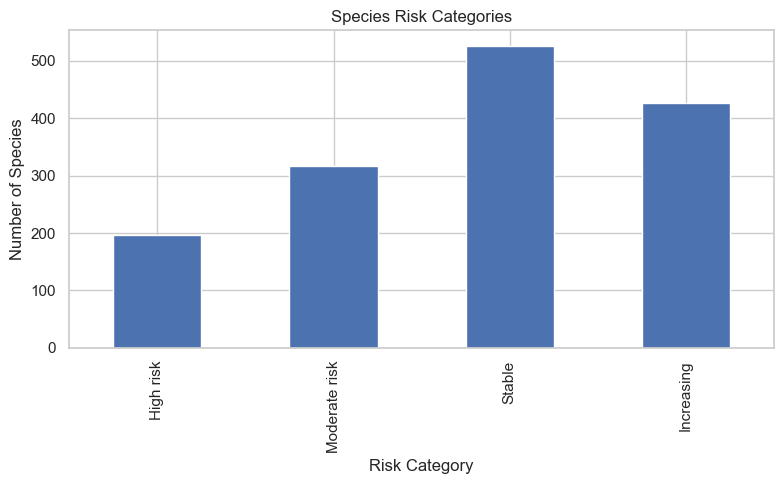

In [29]:
risk_counts = (
    species_risk["Species_Risk"]
    .value_counts()
    .reindex([
        "High risk",
        "Moderate risk",
        "Stable",
        "Increasing"
    ])
)

plt.figure(figsize=(8,5))

risk_counts.plot(kind="bar")

plt.title("Species Risk Categories")
plt.ylabel("Number of Species")
plt.xlabel("Risk Category")

plt.tight_layout()
plt.show()

In [30]:
# Save dataset with risk categories

risk_output = trend_data.copy()

risk_output.to_csv(
    "../data/processed/lpd_population_trends_with_risk.csv",
    index=False
)

print("Saved:")
print("../data/processed/lpd_population_trends_with_risk.csv")
print(risk_output.shape)

Saved:
../data/processed/lpd_population_trends_with_risk.csv
(21284, 15)
